In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings

warnings.filterwarnings("ignore")

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "DATA" / "PROCESSED"
MODELS_DIR = PROJECT_ROOT / "MODELS"

FEATURE_FILE = PROCESSED_DIR / "cars_features.csv"
MODEL_FILE = MODELS_DIR / "car_price_model.joblib"

In [3]:
cars = pd.read_csv(FEATURE_FILE)

print("Dataset shape:", cars.shape)

Dataset shape: (1725, 10)


In [4]:
price_candidates = [
    "selling_price",
    "price",
    "resale_price"
]

TARGET = next(
    (
        col for col in price_candidates
        if col in cars.columns
    ),
    None
)

X = cars.drop(columns=[TARGET])
y = cars[TARGET]

print("Target:", TARGET)

Target: price


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Test rows:", len(X_test))

Test rows: 345


In [6]:
model = joblib.load(MODEL_FILE)

print("Model loaded successfully.")
print(model)

Model loaded successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['id', 'year',
                                                   'distance_travelled(kms)',
                                                   'car_age']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [

In [7]:
y_pred = model.predict(X_test)

print("Predictions generated.")
print(y_pred[:10])

Predictions generated.
[ 380890.          683353.33333333  696806.66666667  919386.66666667
 1305626.66666667 1149033.33333333  718160.         2664716.66666667
 2184076.66666667 1005966.66666667]


In [8]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("========== MODEL EVALUATION ==========")
print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.4f}")

========== MODEL EVALUATION ==========
MAE : 329,445.46
RMSE: 989,864.99
R²  : 0.7081


In [9]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,365000.0,3.808900e+05
1,1195000.0,6.833533e+05
2,575000.0,6.968067e+05
3,900000.0,9.193867e+05
4,1675000.0,1.305627e+06
5,1050000.0,1.149033e+06
6,675000.0,7.181600e+05
7,2600000.0,2.664717e+06
8,2400000.0,2.184077e+06
9,990000.0,1.005967e+06


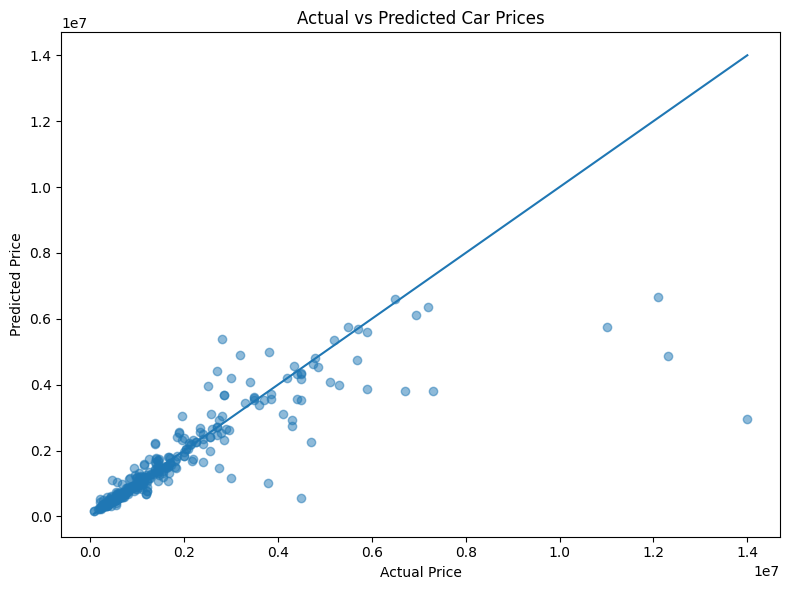

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.tight_layout()
plt.show()

In [11]:
comparison["error"] = (
    comparison["Actual"] -
    comparison["Predicted"]
)

comparison["absolute_error"] = (
    comparison["error"].abs()
)

comparison.head(20)

,Actual,Predicted,error,absolute_error
0,365000.0,3.808900e+05,-1.589000e+04,1.589000e+04
1,1195000.0,6.833533e+05,5.116467e+05,5.116467e+05
2,575000.0,6.968067e+05,-1.218067e+05,1.218067e+05
3,900000.0,9.193867e+05,-1.938667e+04,1.938667e+04
4,1675000.0,1.305627e+06,3.693733e+05,3.693733e+05
5,1050000.0,1.149033e+06,-9.903333e+04,9.903333e+04
6,675000.0,7.181600e+05,-4.316000e+04,4.316000e+04
7,2600000.0,2.664717e+06,-6.471667e+04,6.471667e+04
8,2400000.0,2.184077e+06,2.159233e+05,2.159233e+05
9,990000.0,1.005967e+06,-1.596667e+04,1.596667e+04


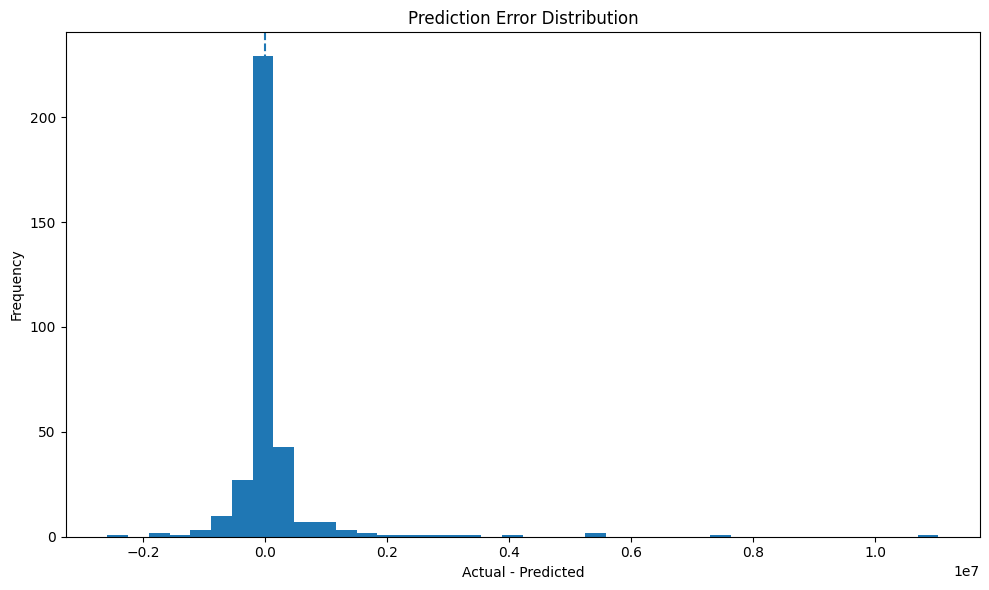

In [12]:
plt.figure(figsize=(10, 6))

plt.hist(
    comparison["error"],
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Prediction Error Distribution")
plt.xlabel("Actual - Predicted")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [13]:
non_zero_actual = y_test != 0

mape = (
    np.mean(
        np.abs(
            (
                y_test[non_zero_actual]
                -
                y_pred[non_zero_actual]
            )
            /
            y_test[non_zero_actual]
        )
    )
    * 100
)

print(f"MAPE: {mape:.2f}%")

MAPE: 16.42%


In [14]:
evaluation_summary = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2",
        "MAPE"
    ],
    "Value": [
        mae,
        rmse,
        r2,
        mape
    ]
})

evaluation_summary

,Metric,Value
0,MAE,329445.458937
1,RMSE,989864.988343
2,R2,0.708124
3,MAPE,16.419811
